In [3]:
import sys
!{sys.executable} -m pip install xgboost

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pickle
import json

df = pd.read_csv('Crop_recommendation.csv')
print(df.shape)
print(df.head())

(2200, 8)
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [5]:
# Add derived features
df['NPK_sum'] = df['N'] + df['P'] + df['K']
df['NP_ratio'] = df['N'] / (df['P'] + 1)

print("New columns added:")
print(df[['N', 'P', 'K', 'NPK_sum', 'NP_ratio']].head())
print(f"\nNew shape: {df.shape}")

New columns added:
    N   P   K  NPK_sum  NP_ratio
0  90  42  43      175  2.093023
1  85  58  41      184  1.440678
2  60  55  44      159  1.071429
3  74  35  40      149  2.055556
4  78  42  42      162  1.813953

New shape: (2200, 10)


In [6]:
# Mapping from soil type to approximate NPK and pH values
# These values are calibrated to match the dataset's scale
SOIL_NPK_MAP = {
    'Black Soil': {
        'N': 80, 'P': 60, 'K': 45, 'ph': 8.1
    },
    'Laterite Soil': {
        'N': 20, 'P': 15, 'K': 35, 'ph': 5.5
    },
    'Yellow Soil': {
        'N': 35, 'P': 30, 'K': 30, 'ph': 6.5
    }
}

def get_soil_features(soil_type):
    """
    Given a soil type string, return mapped NPK and pH values
    with derived features already computed.
    """
    if soil_type not in SOIL_NPK_MAP:
        raise ValueError(f"Unknown soil type: {soil_type}")
    
    vals = SOIL_NPK_MAP[soil_type].copy()
    
    # Add derived features
    vals['NPK_sum'] = vals['N'] + vals['P'] + vals['K']
    vals['NP_ratio'] = vals['N'] / (vals['P'] + 1)
    
    return vals

# Test the mapping
for soil in ['Black Soil', 'Laterite Soil', 'Yellow Soil']:
    print(f"\n{soil}:")
    print(get_soil_features(soil))


Black Soil:
{'N': 80, 'P': 60, 'K': 45, 'ph': 8.1, 'NPK_sum': 185, 'NP_ratio': 1.3114754098360655}

Laterite Soil:
{'N': 20, 'P': 15, 'K': 35, 'ph': 5.5, 'NPK_sum': 70, 'NP_ratio': 1.25}

Yellow Soil:
{'N': 35, 'P': 30, 'K': 30, 'ph': 6.5, 'NPK_sum': 95, 'NP_ratio': 1.1290322580645162}


In [7]:
# All features including engineered ones
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 
                'rainfall', 'NPK_sum', 'NP_ratio']

X = df[feature_cols]
y = df['label']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save label encoder
with open('crop_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save feature names
with open('xgb_feature_names.json', 'w') as f:
    json.dump(feature_cols, f)

# Save soil mapping
with open('soil_npk_map.json', 'w') as f:
    json.dump(SOIL_NPK_MAP, f)

print("Classes:", list(le.classes_))
print("Features:", feature_cols)
print("X shape:", X.shape)

Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'NPK_sum', 'NP_ratio']
X shape: (2200, 9)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (1760, 9)
Test:  (440, 9)


In [9]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

print("\nTraining complete!")

[0]	validation_0-mlogloss:2.30256	validation_1-mlogloss:2.34098
[50]	validation_0-mlogloss:0.02953	validation_1-mlogloss:0.07108
[100]	validation_0-mlogloss:0.00972	validation_1-mlogloss:0.04191
[150]	validation_0-mlogloss:0.00841	validation_1-mlogloss:0.03946
[200]	validation_0-mlogloss:0.00798	validation_1-mlogloss:0.03915
[250]	validation_0-mlogloss:0.00774	validation_1-mlogloss:0.03881
[299]	validation_0-mlogloss:0.00760	validation_1-mlogloss:0.03887

Training complete!


In [10]:
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"XGBoost Test Accuracy: {acc*100:.2f}%")
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

XGBoost Test Accuracy: 99.09%

Per-class report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.90      0.92        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.95      0.95      0.95        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.0

<Figure size 1000x600 with 0 Axes>

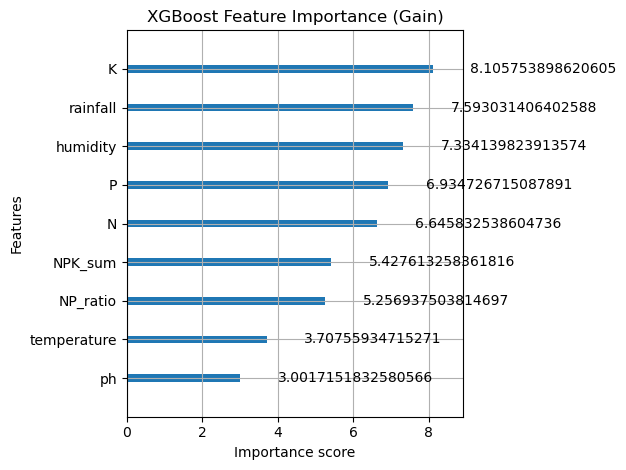

In [11]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='gain', 
                    max_num_features=9, 
                    title='XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png')
plt.show()

In [12]:
xgb_model.save_model('crop_xgb_model.json')
print("XGBoost model saved as crop_xgb_model.json ")

XGBoost model saved as crop_xgb_model.json 


In [21]:
import numpy as np

def predict_crop_from_soil_image(soil_type, temperature, humidity, rainfall):
    """Mode 1: soil image → mapping → XGBoost (Top 3 crops)"""
    soil_vals = get_soil_features(soil_type)
    
    input_data = np.array([[
        soil_vals['N'], soil_vals['P'], soil_vals['K'],
        temperature, humidity, soil_vals['ph'], rainfall,
        soil_vals['NPK_sum'], soil_vals['NP_ratio']
    ]])
    
    proba = xgb_model.predict_proba(input_data)[0]
    
    # Get top 3 predictions
    top3_idx = np.argsort(proba)[::-1][:3]
    
    top3 = []
    for idx in top3_idx:
        top3.append({
            "crop": le.inverse_transform([idx])[0],
            "confidence": round(float(proba[idx]) * 100, 2)
        })
    
    return {
        "top_3_crops": top3,
        "mode": "image"
    }


def predict_crop_from_manual(N, P, K, temperature, humidity, ph, rainfall):
    """Mode 2: manual input → XGBoost (Top 3 crops)"""
    NPK_sum = N + P + K
    NP_ratio = N / (P + 1)
    
    input_data = np.array([[
        N, P, K, temperature, humidity, ph, rainfall,
        NPK_sum, NP_ratio
    ]])
    
    proba = xgb_model.predict_proba(input_data)[0]
    
    # Get top 3 predictions
    top3_idx = np.argsort(proba)[::-1][:3]
    
    top3 = []
    for idx in top3_idx:
        top3.append({
            "crop": le.inverse_transform([idx])[0],
            "confidence": round(float(proba[idx]) * 100, 2)
        })
    
    return {
        "top_3_crops": top3,
        "mode": "manual"
    }


# ===== TESTING =====

result1 = predict_crop_from_soil_image(
    soil_type='Black Soil',
    temperature=25,
    humidity=80,
    rainfall=200
)

print("Mode 1 (Image):")
for i, crop in enumerate(result1["top_3_crops"], 1):
    print(f"{i}. {crop['crop']} ({crop['confidence']}%)")


result2 = predict_crop_from_manual(
    N=90, P=42, K=43,
    temperature=20, humidity=82,
    ph=6.5, rainfall=202
)

print("\nMode 2 (Manual):")
for i, crop in enumerate(result2["top_3_crops"], 1):
    print(f"{i}. {crop['crop']} ({crop['confidence']}%)")

Mode 1 (Image):
1. jute (95.15%)
2. rice (3.62%)
3. papaya (0.12%)

Mode 2 (Manual):
1. rice (99.88%)
2. jute (0.04%)
3. coconut (0.01%)


In [22]:
train_pred = xgb_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy:  {test_acc*100:.2f}%")
print(f"Gap:            {(train_acc - test_acc)*100:.2f}%")

Train accuracy: 100.00%
Test accuracy:  99.09%
Gap:            0.91%


In [23]:
import numpy as np

y_shuffled = np.random.permutation(y_encoded)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_shuffled, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier()
model.fit(X_train_s, y_train_s)

y_pred_s = model.predict(X_test_s)
print("Accuracy with shuffled labels:", accuracy_score(y_test_s, y_pred_s))

Accuracy with shuffled labels: 0.045454545454545456


In [16]:
!pip install shap

In [24]:
import shap

In [25]:
explainer = shap.TreeExplainer(xgb_model)

In [30]:
explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test.sample(100, random_state=42)

shap_values = explainer.shap_values(X_sample)

In [32]:
import numpy as np

shap_2d = np.mean(np.abs(shap_values), axis=2)

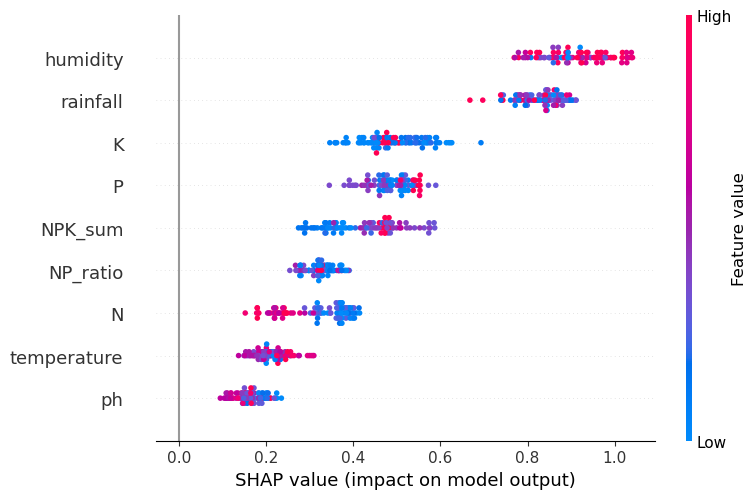

In [33]:
shap.summary_plot(shap_2d, X_sample)

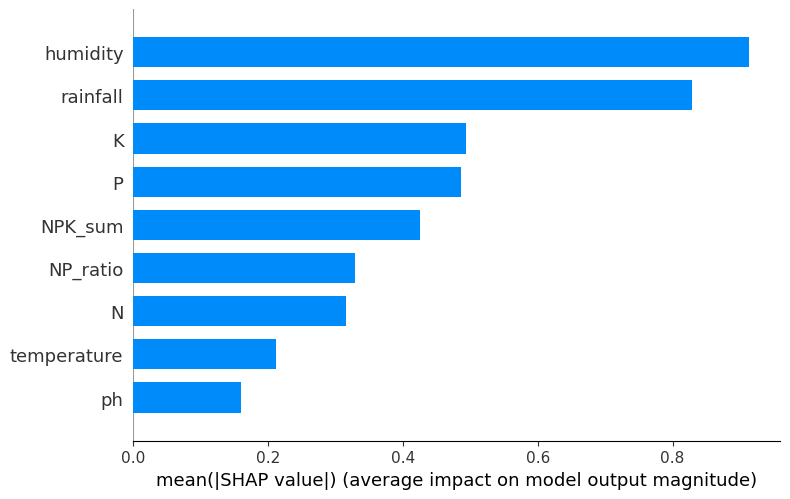

In [34]:
shap.summary_plot(shap_2d, X_sample, plot_type="bar")

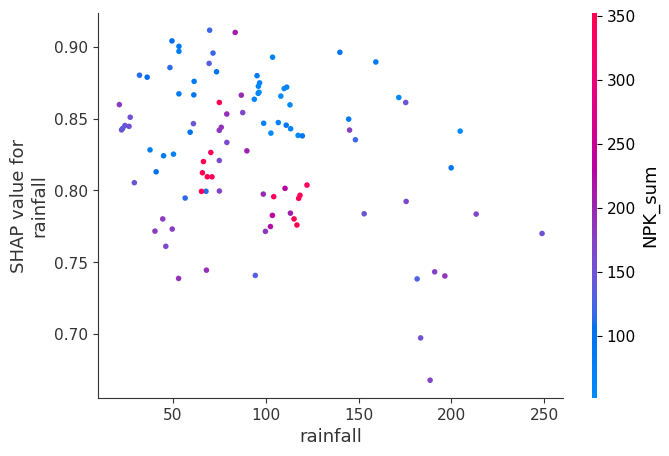

In [35]:
shap.dependence_plot("rainfall", shap_2d, X_sample)

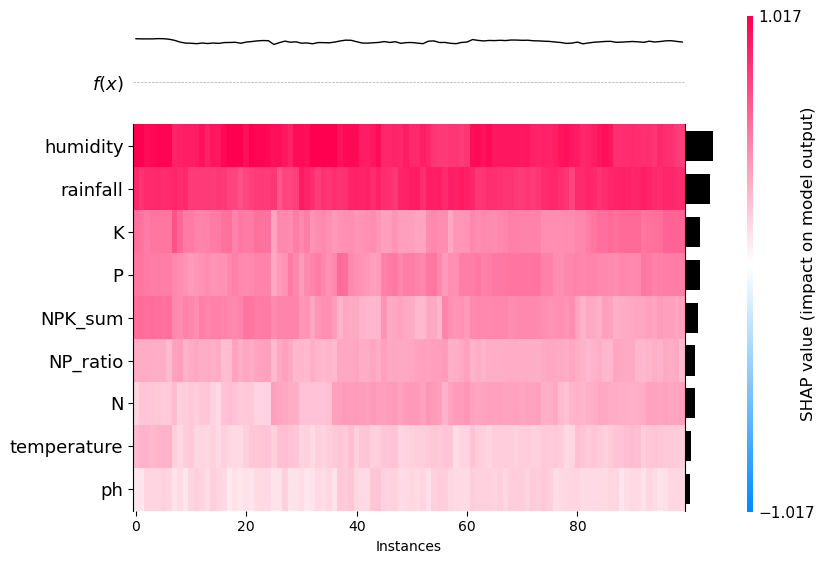

<Axes: xlabel='Instances'>

In [36]:
shap.plots.heatmap(
    shap.Explanation(values=shap_2d, data=X_sample.values, feature_names=X_sample.columns)
)